# Python Libraries for Data Science: pandas, matplotlib & seaborn

This notebook covers two linked sessions:

- **Part I — Python Libraries I: Data Manipulation and Cleaning.** Introduction to pandas:
  loading and handling data, cleaning and pre-processing, handling missing data, merging and
  joining datasets, and data transformation techniques.
- **Part II — Python Libraries II: Data Visualization.** Introduction to matplotlib and seaborn:
  basic plotting techniques, visualizing distributions and trends, and a case study problem.

Both parts work on the same running dataset — Titanic passenger records from 1912 — so the
cleaned, transformed data from Part I is exactly what feeds the visualizations in Part II.
This mirrors a real project: you don't visualize raw, messy data; you visualize what survives
the cleaning pass.


---
# Part I — Data Manipulation and Cleaning

## Introduction to pandas

pandas is the library almost every Python data project starts with. Its core object is the
**DataFrame** — a labeled, 2-dimensional table you can filter, transform, and summarize with
code rather than by hand. We'll work through pandas' core capabilities in the order you'd
typically need them on a new dataset.


## 1. Loading and handling data

The first step in any project is getting data into a DataFrame and getting your bearings.
In practice you'll load most data with `pd.read_csv()`, `pd.read_excel()`, or similar; here we
use seaborn's dataset loader for convenience, but everything after this cell applies equally
to data loaded any other way.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load the Titanic dataset
# (in your own projects this is usually: df = pd.read_csv('data.csv'))
df = sns.load_dataset('titanic')

# Always work on a copy, so the original stays available if you need to start over
data = df.copy()

# Give every row an explicit ID -- useful later for merging/joining
data.insert(0, 'passenger_id', range(1, len(data) + 1))

data.shape

(891, 16)

`shape` gives you `(rows, columns)` immediately. Next, look at actual rows with `head()`
and `tail()`, rather than trusting the load worked.

In [2]:
data.head()

,passenger_id,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,1,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,2,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,4,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,5,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
data.tail(3)

,passenger_id,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
888,889,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,890,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,891,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


Other quick "handling data" basics worth knowing from day one:

- **Selecting a column**: `data['age']` (returns a Series) or `data[['age', 'fare']]` (returns
  a DataFrame, note the double brackets)
- **Selecting rows by position**: `data.iloc[0:5]`
- **Selecting rows by a condition**: `data[data['age'] > 60]`
- **Sorting**: `data.sort_values('fare', ascending=False)`

In [4]:
# A few of the above, in action
print('Passengers over 60:', len(data[data['age'] > 60]))
print()
data.sort_values('fare', ascending=False)[['passenger_id', 'fare', 'pclass', 'survived']].head()

Passengers over 60: 22



,passenger_id,fare,pclass,survived
679,680,512.3292,1,1
258,259,512.3292,1,1
737,738,512.3292,1,1
88,89,263.0000,1,1
438,439,263.0000,1,0


**Try it yourself:** select just the `sex` and `survived` columns for passengers younger
than 10. (Hint: combine a boolean condition with double-bracket column selection.)

## 2. Understanding your columns

Before cleaning anything, know what you're working with: each column's **data type**, and
some **summary statistics**.

In [5]:
data.dtypes

passenger_id       int64
survived           int64
pclass             int64
sex               object
age              float64
sibsp              int64
parch              int64
fare             float64
embarked          object
class           category
who               object
adult_male          bool
deck            category
embark_town       object
alive             object
alone               bool
dtype: object

`int64`/`float64` are numeric, `bool` is True/False, `category`/`object` hold text labels.
This split drives a lot of what follows — numeric and categorical columns get cleaned and
visualized with different tools.

`describe()` summarizes the numeric columns: count, mean, std, min/max, and quartiles.

In [6]:
data.describe()

,passenger_id,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Two things worth reading off this table immediately: `count` differs between columns
(714 for `age` vs. 891 for most others) — our first hint of missing data — and `survived` is
0/1, so its `mean` (≈0.38) is the overall survival *rate*.

It's worth turning the type-split into reusable variables, since you'll filter by type often:

In [7]:
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)

Numerical features: ['passenger_id', 'survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## 3. Handling missing data

Missing data is one of the first real problems any dataset throws at you. pandas marks missing
entries as `NaN`. `isnull()` returns a same-shaped DataFrame of True/False flags, summed here
per column.

In [8]:
missing_counts = data.isnull().sum().sort_values(ascending=False)
missing_counts

deck            688
age             177
embarked          2
embark_town       2
sex               0
passenger_id      0
pclass            0
survived          0
fare              0
parch             0
sibsp             0
class             0
adult_male        0
who               0
alive             0
alone             0
dtype: int64

Percentages are usually more intuitive than raw counts -- "77% missing" communicates more
at a glance than "688 missing".

In [9]:
missing_percent = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

missing_summary = pd.concat([missing_counts, missing_percent], axis=1)
missing_summary.columns = ['Missing Count', 'Missing %']
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing %
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


### Visualizing missingness

A quick visual scan is often faster than a table, especially with many columns. seaborn's
`heatmap()` can repurpose itself for this: feed it the boolean `isnull()` grid and the colors
show where data is missing.

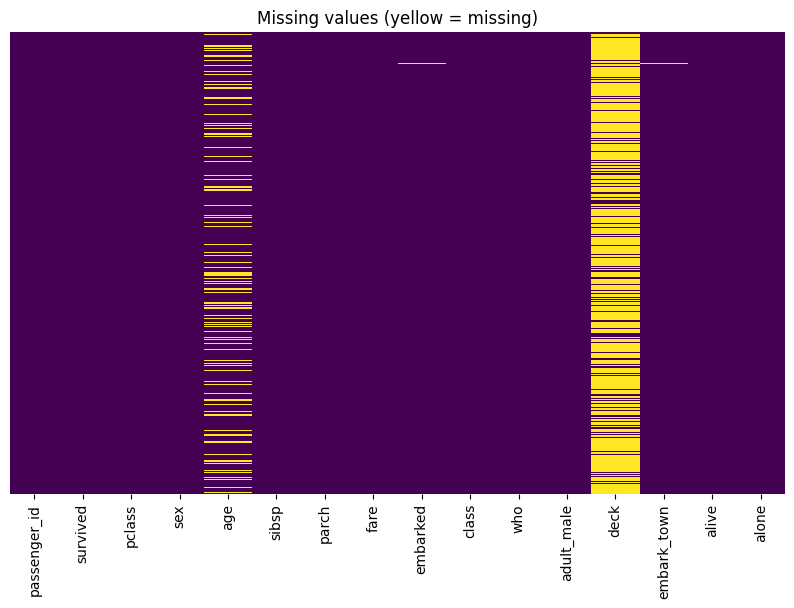

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing values (yellow = missing)')
plt.show()

**`missingno`** is a small library purpose-built for exactly this:

- `msno.matrix()` — same idea as the heatmap above, with a sparkline showing row-completeness
- `msno.bar()` — bar chart of how complete each column is
- `msno.heatmap()` — *correlation between missingness*: do columns tend to be missing together?

In [16]:
import missingno as msno

msno.matrix(data)
plt.show()


ModuleNotFoundError: No module named 'missingno'

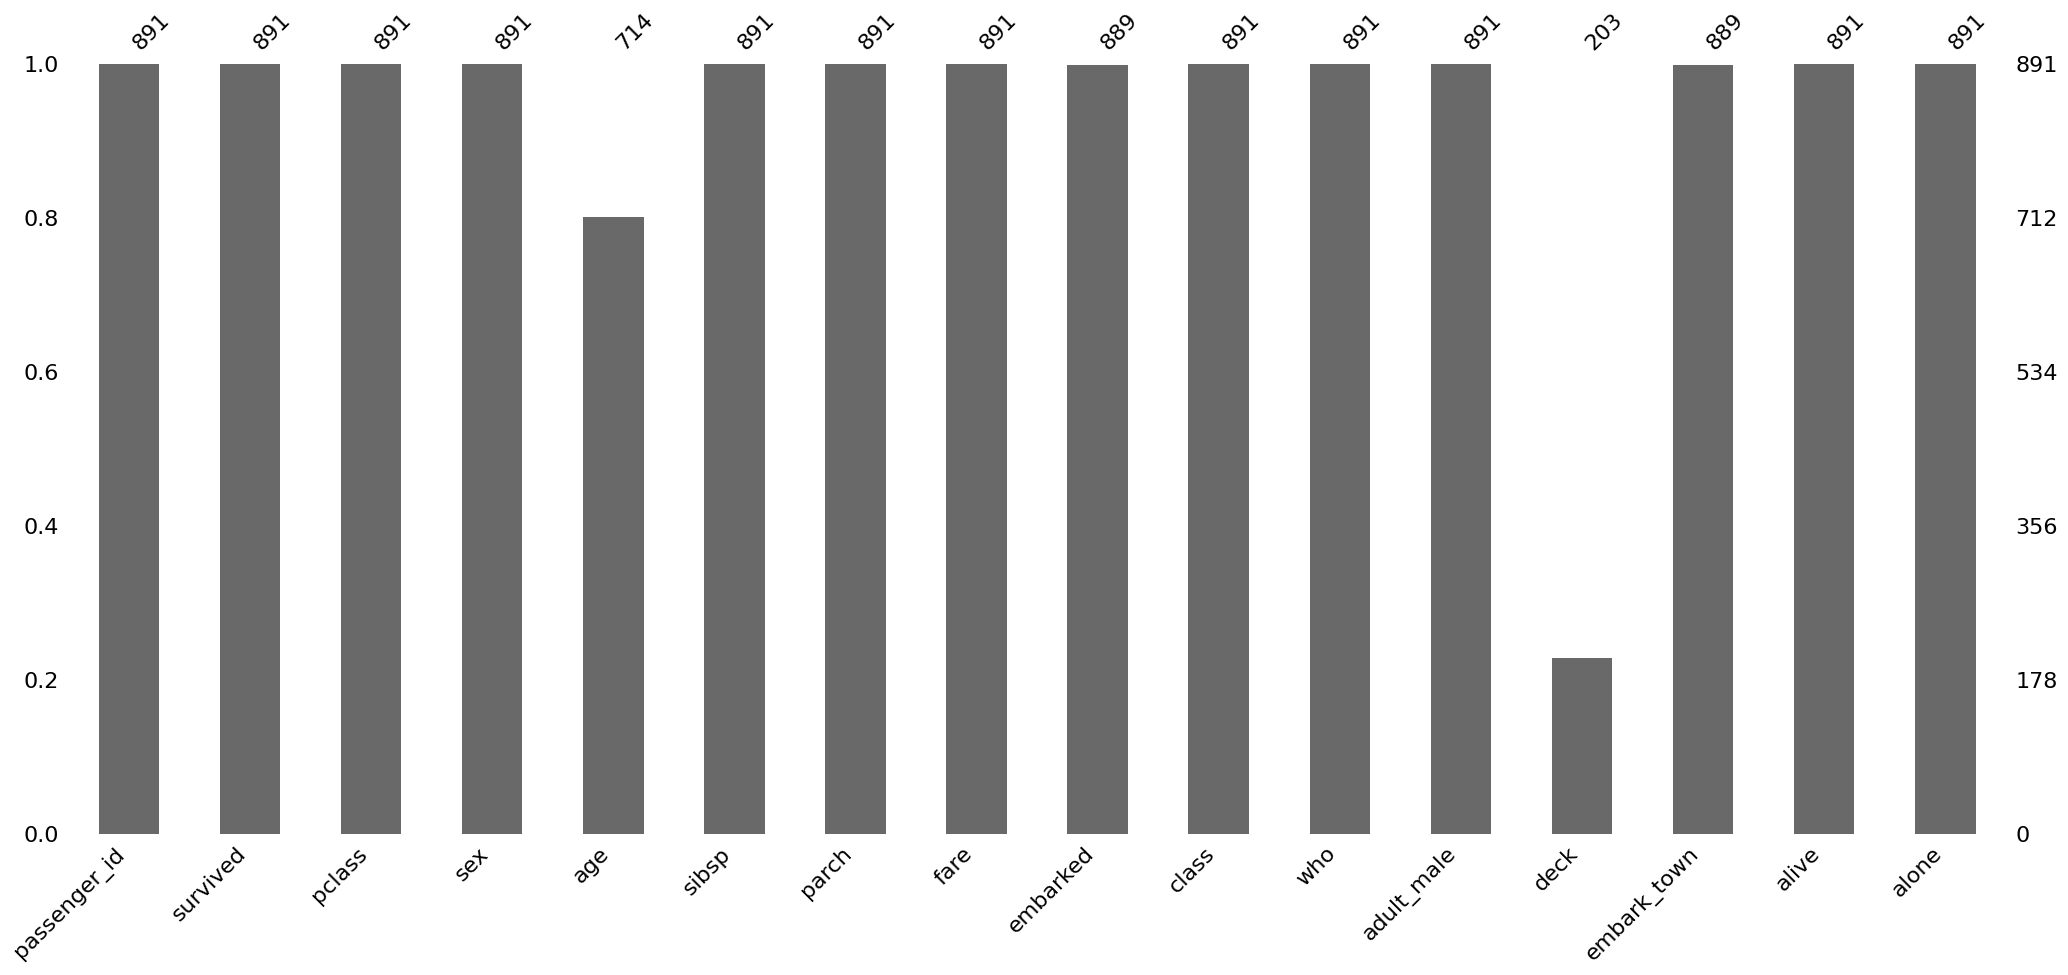

In [12]:
msno.bar(data)
plt.show()

In [17]:
msno.heatmap(data)
plt.show()

NameError: name 'msno' is not defined

Reading the `missingno` heatmap: near **1** means two columns tend to be missing
together; near **-1** means when one is missing the other tends to be present; near **0** means
no relationship. Here `deck` is missing for the large majority of rows and isn't strongly tied
to the other columns' missingness — that's useful context for the decision we make next.

## 4. Cleaning and pre-processing

Three pandas tools handle most cleaning:

- **`drop()`** — remove columns/rows entirely (when missingness is too severe to fix sensibly)
- **`fillna()`** — fill in missing values with something reasonable
- **`dropna()`** — remove rows that still have missing values, once everything else is handled

There's no single "correct" strategy — it depends on the data and what you're trying to predict.
Below are common, defensible choices, meant to illustrate the *tools*, not to be the only
right answer.

In [18]:
clean = data.copy()

# 'deck' is missing for ~77% of rows -- too sparse to fill in reliably, so we drop it
clean = clean.drop(columns=['deck'])

# 'age' is missing for ~20% of rows -- a numeric column, so a common simple choice
# is filling with the median (robust to outliers/skew)
clean['age'] = clean['age'].fillna(clean['age'].median())

# 'embarked' / 'embark_town' are missing for just 2 rows -- fill with the most common value
clean['embarked'] = clean['embarked'].fillna(clean['embarked'].mode()[0])
clean['embark_town'] = clean['embark_town'].fillna(clean['embark_town'].mode()[0])

# Confirm there's nothing left
print('Remaining missing values:', clean.isnull().sum().sum())
clean.head()

Remaining missing values: 0


,passenger_id,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,1,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,2,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,3,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,4,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,5,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


Worth flagging: filling missing values always trades off something (median-filling
`age` slightly distorts its true distribution), so in a real project this is a decision worth
documenting and revisiting once you see how downstream analysis or modeling performs.

Other common pre-processing moves worth knowing:

- **Removing duplicate rows**: `clean.drop_duplicates()`
- **Renaming columns**: `clean.rename(columns={'sibsp': 'siblings_spouses'})`
- **Fixing inconsistent text**: `clean['sex'].str.lower().str.strip()`
- **Dropping rows with any remaining missing values** (once you're confident it's safe):
  `clean.dropna()`

In [19]:
# Example: standardize text casing, in case of inconsistent capitalization upstream
clean['embark_town'] = clean['embark_town'].str.strip().str.title()
clean['embark_town'].value_counts()

embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

## 5. Merging and joining datasets

Real data rarely arrives as one tidy table — it's often split across multiple files or
database tables that need to be combined. pandas mirrors SQL-style joins through `pd.merge()`,
plus simpler stacking through `pd.concat()`.

To practice this, we'll split our single `clean` DataFrame into three separate tables — the
kind of split you might see across different source systems — then put them back together.

In [20]:
# Table 1: passenger identity / demographic info
passengers = clean[['passenger_id', 'sex', 'age', 'who', 'adult_male']].copy()

# Table 2: travel/ticket info
travel = clean[['passenger_id', 'pclass', 'fare', 'embarked', 'embark_town', 'class']].copy()

# Table 3: outcome info -- deliberately drop a few passenger_ids,
# to demonstrate how different join types handle missing matches
outcomes = clean[['passenger_id', 'survived', 'alive', 'alone']].copy()
outcomes = outcomes[outcomes['passenger_id'] % 50 != 0]  # drop every 50th id

print('passengers:', passengers.shape)
print('travel:', travel.shape)
print('outcomes:', outcomes.shape, '<- intentionally missing some passenger_ids')

passengers: (891, 5)
travel: (891, 6)
outcomes: (874, 4) <- intentionally missing some passenger_ids


In [21]:
passengers.head()

,passenger_id,sex,age,who,adult_male
0,1,male,22.0,man,True
1,2,female,38.0,woman,False
2,3,female,26.0,woman,False
3,4,female,35.0,woman,False
4,5,male,35.0,man,True


In [22]:
travel.head()

,passenger_id,pclass,fare,embarked,embark_town,class
0,1,3,7.2500,S,Southampton,Third
1,2,1,71.2833,C,Cherbourg,First
2,3,3,7.9250,S,Southampton,Third
3,4,1,53.1000,S,Southampton,First
4,5,3,8.0500,S,Southampton,Third


### `pd.merge()` — SQL-style joins

`merge()` combines two DataFrames on a shared key column. The `how` parameter controls what
happens to rows that don't have a match in the other table:

| `how` | Keeps |
|---|---|
| `'inner'` | only rows with a match in **both** tables |
| `'left'` | all rows from the left table, filling unmatched right-side columns with `NaN` |
| `'right'` | all rows from the right table, filling unmatched left-side columns with `NaN` |
| `'outer'` | all rows from **either** table, filling gaps with `NaN` |

In [23]:
merged_inner = passengers.merge(travel, on='passenger_id', how='inner')
merged_inner = merged_inner.merge(outcomes, on='passenger_id', how='inner')

print('Inner join shape:', merged_inner.shape)
merged_inner.head()

Inner join shape: (874, 13)


,passenger_id,sex,age,who,adult_male,pclass,fare,embarked,embark_town,class,survived,alive,alone
0,1,male,22.0,man,True,3,7.2500,S,Southampton,Third,0,no,False
1,2,female,38.0,woman,False,1,71.2833,C,Cherbourg,First,1,yes,False
2,3,female,26.0,woman,False,3,7.9250,S,Southampton,Third,1,yes,True
3,4,female,35.0,woman,False,1,53.1000,S,Southampton,First,1,yes,False
4,5,male,35.0,man,True,3,8.0500,S,Southampton,Third,0,no,True


In [26]:
# Compare: a left join keeps every passenger, even ones missing from 'outcomes'
merged_left = passengers.merge(travel, on='passenger_id', how='left')
merged_left = merged_left.merge(outcomes, on='passenger_id', how='left')

print('Left join shape:', merged_left.shape)
print('Rows with missing survival outcome after left join:', merged_left['survived'].isnull().sum())
merged_left[merged_left['survived'].isnull()].head()

Left join shape: (891, 13)
Rows with missing survival outcome after left join: 17


,passenger_id,sex,age,who,adult_male,pclass,fare,embarked,embark_town,class,survived,alive,alone
49,50,female,18.0,woman,False,3,17.8,S,Southampton,Third,NaN,NaN,NaN
99,100,male,34.0,man,True,2,26.0,S,Southampton,Second,NaN,NaN,NaN
149,150,male,42.0,man,True,2,13.0,S,Southampton,Second,NaN,NaN,NaN
199,200,female,24.0,woman,False,2,13.0,S,Southampton,Second,NaN,NaN,NaN
249,250,male,54.0,man,True,2,26.0,S,Southampton,Second,NaN,NaN,NaN


Notice the shape difference: the inner join silently dropped the passengers missing from
`outcomes` (891 → 873 rows), while the left join kept all 891 and simply left `survived`/`alive`/
`alone` as `NaN` for the unmatched ones. **This is exactly the kind of silent row loss to watch
for** when merging real datasets — always compare row counts before and after a join.

### `pd.concat()` — stacking instead of joining

`concat()` is for when you have pieces that share the same columns and just need to be stacked
(rows) or placed side-by-side (columns), rather than matched on a key.

In [24]:
# Simulate two batches of new passengers, e.g. arriving from two different source files
batch_1 = clean.iloc[:3][['passenger_id', 'sex', 'age', 'survived']]
batch_2 = clean.iloc[3:6][['passenger_id', 'sex', 'age', 'survived']]

stacked = pd.concat([batch_1, batch_2], axis=0)
print('Stacked shape:', stacked.shape)
stacked

Stacked shape: (6, 4)


,passenger_id,sex,age,survived
0,1,male,22.0,0
1,2,female,38.0,1
2,3,female,26.0,1
3,4,female,35.0,1
4,5,male,35.0,0
5,6,male,28.0,0


`axis=0` stacks rows (the default, like appending); `axis=1` would instead glue columns
side-by-side, which only makes sense when both pieces share the same row index/order.

**Try it yourself:** re-run the left join above using `how='outer'` instead, and compare the
resulting shape and missing-value count to both the inner and left versions.

## 6. Data transformation techniques

Cleaning fixes problems; **transformation** reshapes data into a form that's easier to
analyze or model. A few of the most common techniques:

- **Mapping/applying functions** to create derived columns
- **Binning** continuous values into categories
- **Encoding** categorical text into numbers
- **Scaling/transforming** skewed numeric distributions
- **Grouping and aggregating**

In [27]:
# Mapping: derive a new column from an existing one
merged_left['sex_code'] = merged_left['sex'].map({'male': 0, 'female': 1})

# apply(): run an arbitrary function over a column
merged_left['fare_per_class'] = merged_left.apply(lambda row: row['fare'] / row['pclass'], axis=1)

merged_left[['sex', 'sex_code', 'fare', 'pclass', 'fare_per_class']].head()

,sex,sex_code,fare,pclass,fare_per_class
0,male,0,7.2500,3,2.416667
1,female,1,71.2833,1,71.283300
2,female,1,7.9250,3,2.641667
3,female,1,53.1000,1,53.100000
4,male,0,8.0500,3,2.683333


In [28]:
# Binning: turn a continuous variable into categories with pd.cut
merged_left['age_group'] = pd.cut(
    merged_left['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

merged_left[['age', 'age_group']].head(8)

,age,age_group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child


In [29]:
# Encoding: turn categorical text into numeric columns models/stats can use
# get_dummies creates one binary (0/1) column per category -- "one-hot encoding"
encoded = pd.get_dummies(merged_left, columns=['embarked'], prefix='embarked')
encoded.filter(like='embarked').head()

,embarked_C,embarked_Q,embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


### Transforming skewed numeric data

`fare` is heavily right-skewed (most tickets were cheap, a few were very expensive). A log
transform is a standard fix — it compresses the long tail and makes the distribution closer
to symmetric, which many statistical methods assume.

In [30]:
print('Skewness before transform:', merged_left['fare'].skew().round(2))

merged_left['fare_log'] = np.log1p(merged_left['fare'])  # log1p handles fare == 0 safely

print('Skewness after log1p transform:', merged_left['fare_log'].skew().round(2))

Skewness before transform: 4.79
Skewness after log1p transform: 0.39


Skewness dropped from roughly 4.8 to 0.4 — much closer to symmetric. We'll see this
visually in Part II.

### Grouping and aggregating

`groupby()` is one of the most-used pandas operations: split rows into groups, then summarize
each group.

In [31]:
merged_left.groupby('pclass')['fare'].agg(['mean', 'median', 'count'])

,mean,median,count
pclass,,,
1,84.154687,60.2875,216
2,20.662183,14.2500,184
3,13.675550,8.0500,491


In [32]:
# Multiple group keys, multiple aggregated columns
merged_left.groupby(['pclass', 'sex'])[['fare', 'age']].mean().round(1)

fare   age
pclass sex                
1      female  106.1  34.0
       male     67.2  39.0
2      female   22.0  28.7
       male     19.7  30.5
3      female   16.1  23.6
       male     12.7  26.9

**Try it yourself:** group by `age_group` instead, and compute the mean `survived` rate
per group — this previews the kind of comparison we'll visualize directly in Part II.

This is also a natural point to save our fully cleaned and transformed table, since Part II
builds on it directly.

In [33]:
final = merged_left.copy()
final.shape

(891, 17)

---
# Part II — Data Visualization

## Introduction to matplotlib and seaborn

With cleaned, transformed data in hand, the next step is **seeing** it. matplotlib is the
foundational plotting library nearly everything else in the Python visualization ecosystem
builds on; seaborn sits on top of it, trading some flexibility for statistical plots that take
far less code to produce.

We'll cover basic plotting mechanics first, then move into visualizing distributions and
trends, and close with a guided case study.


## 1. Basic plotting techniques: matplotlib

Every matplotlib plot starts from a **figure** (the overall canvas) and one or more **axes**
(the individual plot areas within it). The simplest pattern:

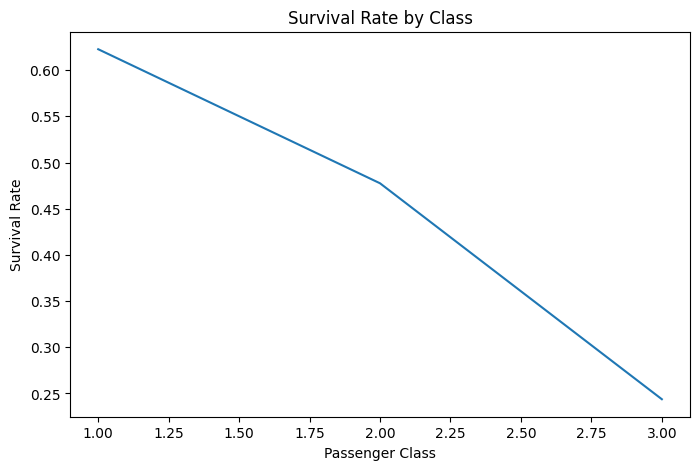

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(merged_left.groupby('pclass')['survived'].mean())
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Class')
plt.show()

For more control — especially multiple plots in a grid — use `plt.subplots()`, which
returns a figure and an array of axes you can plot onto individually.

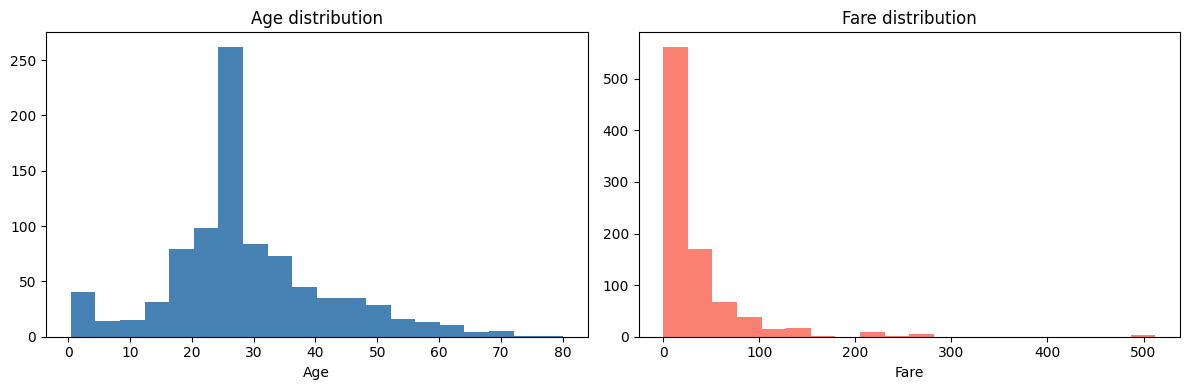

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].hist(merged_left['age'], bins=20, color='steelblue')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

axes[1].hist(merged_left['fare'], bins=20, color='salmon')
axes[1].set_title('Fare distribution')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

Common matplotlib plot types worth knowing directly: `plt.plot()` (lines), `plt.bar()`
(bars), `plt.scatter()` (points), `plt.hist()` (histograms), `plt.pie()` (pie charts). pandas
also wraps several of these directly on DataFrames/Series (e.g. `series.plot(kind='bar')`),
which is often the fastest path for a quick look.

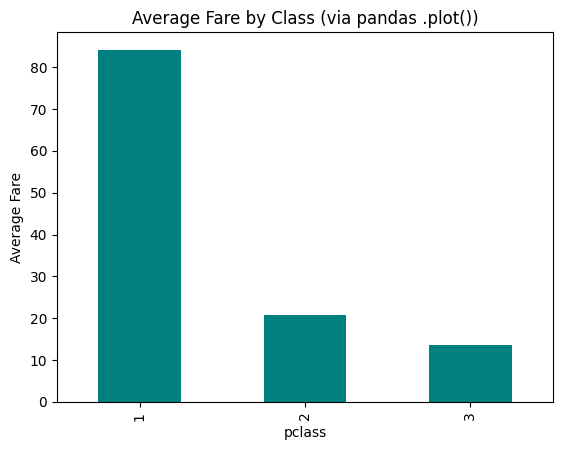

In [29]:
merged_left.groupby('pclass')['fare'].mean().plot(kind='bar', color='teal')
plt.ylabel('Average Fare')
plt.title('Average Fare by Class (via pandas .plot())')
plt.show()

## 2. Basic plotting techniques: seaborn

seaborn plots accept a DataFrame directly via `data=`, and column names as strings for `x`/`y`
— no need to pull out raw arrays first, and statistical extras (confidence intervals, fitted
trend lines, color encoding by category) come built-in.

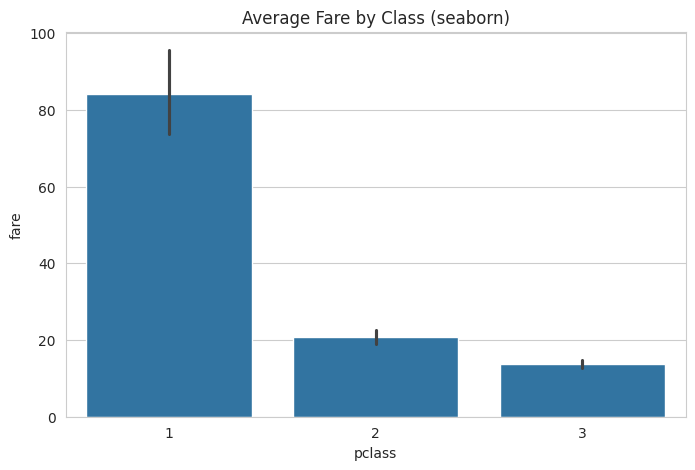

In [30]:
sns.set_style('whitegrid')  # a global style applied to every seaborn plot below

plt.figure(figsize=(8, 5))
sns.barplot(x='pclass', y='fare', data=merged_left)
plt.title('Average Fare by Class (seaborn)')
plt.show()

Notice the black error bars seaborn added automatically — they show the confidence
interval around each estimate, something you'd have to compute and add manually in matplotlib.

`sns.set_style()` (used above) and `sns.set_palette()` let you control the look of every
subsequent plot at once, rather than restyling each one individually.

## 3. Visualizing distributions

### Numeric distributions: histograms, KDE, box plots, violin plots

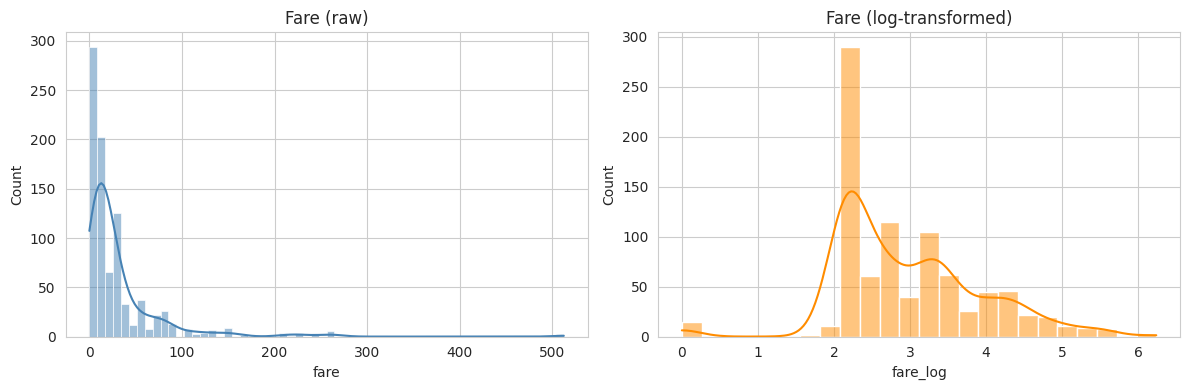

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(merged_left['fare'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Fare (raw)')

sns.histplot(merged_left['fare_log'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Fare (log-transformed)')

plt.tight_layout()
plt.show()

This is the payoff from the log transform in Part I, made visible: the raw `fare`
distribution (left) is sharply right-skewed, while the log-transformed version (right) is much
closer to symmetric — exactly what the skewness numbers predicted.

Box plots and violin plots both compare a numeric distribution **across categories** in one
chart; violin plots additionally show the full shape of the distribution, not just summary
quartiles.

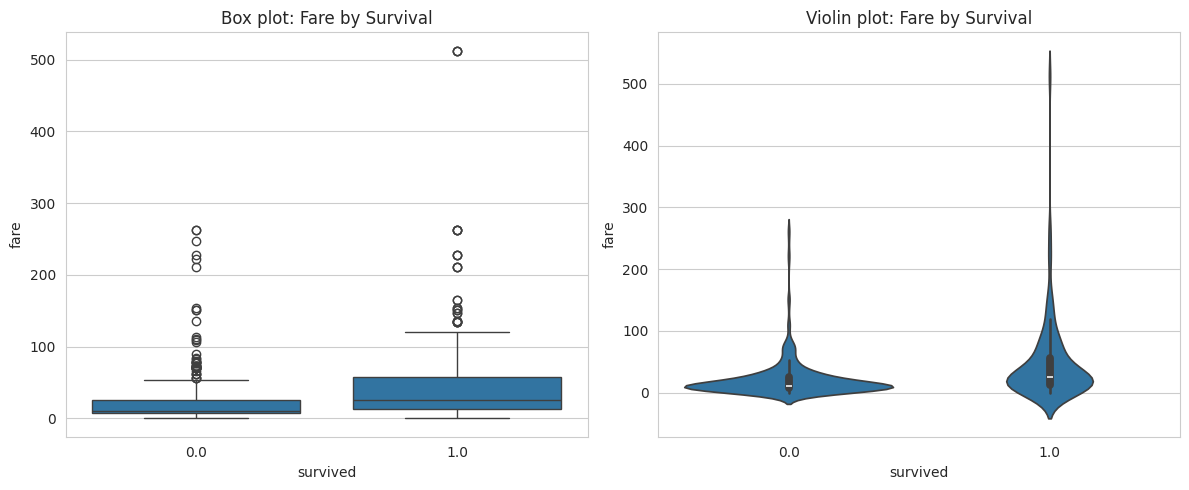

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='survived', y='fare', data=merged_left, ax=axes[0])
axes[0].set_title('Box plot: Fare by Survival')

sns.violinplot(x='survived', y='fare', data=merged_left, ax=axes[1])
axes[1].set_title('Violin plot: Fare by Survival')

plt.tight_layout()
plt.show()

The box plot's box covers the middle 50% of values (interquartile range) with a median
line; the violin plot adds the full density shape around it, so you can see, for instance, that
non-survivors are heavily concentrated at low fares rather than evenly spread across the box's
range.

### Categorical distributions: count plots

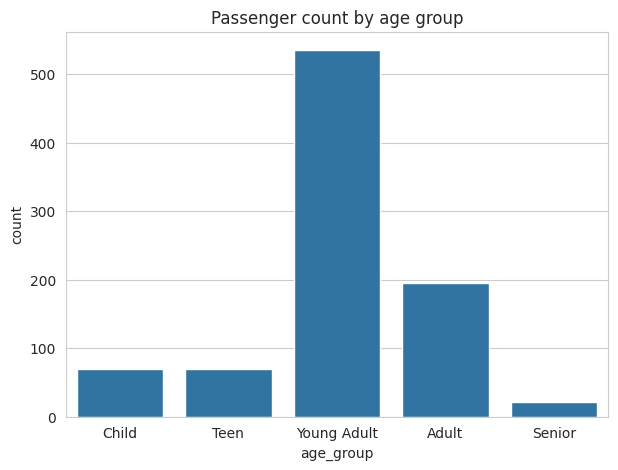

In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(x='age_group', data=merged_left, order=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
plt.title('Passenger count by age group')
plt.show()

## 4. Visualizing trends and relationships

### Scatter plots and trend lines

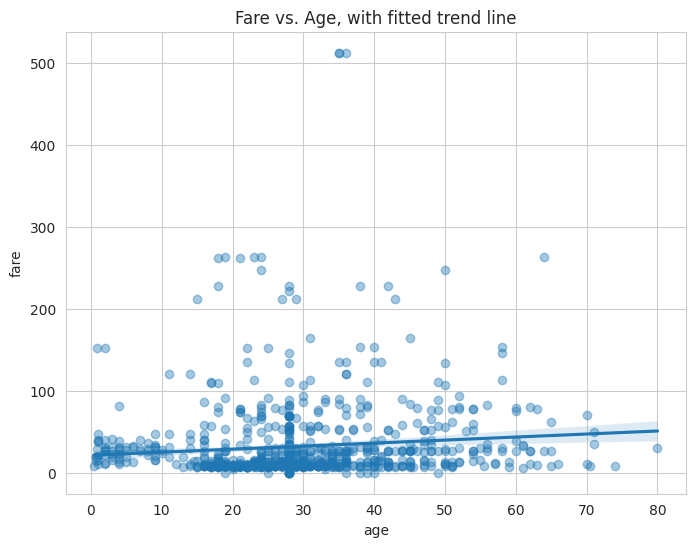

In [34]:
plt.figure(figsize=(8, 6))
sns.regplot(x='age', y='fare', data=merged_left, scatter_kws={'alpha': 0.4})
plt.title('Fare vs. Age, with fitted trend line')
plt.show()

`regplot` adds a fitted regression line and confidence band automatically — a quick way
to check whether two numeric variables show any linear relationship (here, barely any).

### Correlation heatmaps

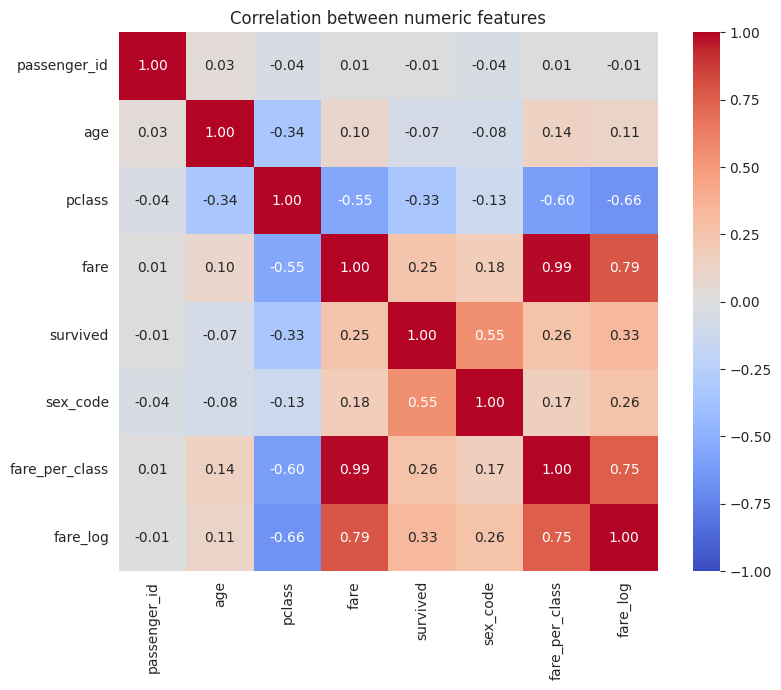

In [35]:
corr = merged_left.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title('Correlation between numeric features')
plt.show()

### Trends across categories: bar and point plots

`sns.catplot` compares a numeric column across two categorical dimensions at once — here,
survival rate by class, split further by sex.

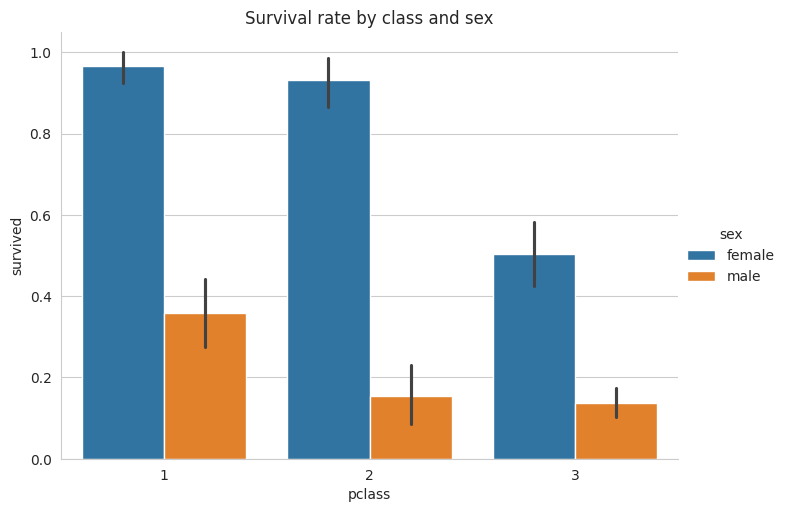

In [36]:
sns.catplot(x='pclass', y='survived', hue='sex', data=merged_left, kind='bar', height=5, aspect=1.4)
plt.title('Survival rate by class and sex')
plt.show()

This single chart tells a richer story than any chart so far on its own: the survival
advantage by class holds for both sexes, but the gap *between sexes* within each class is far
larger than the gap *between classes* — a strong candidate finding to flag in a writeup.

### Many relationships at once: pair plots and FacetGrid

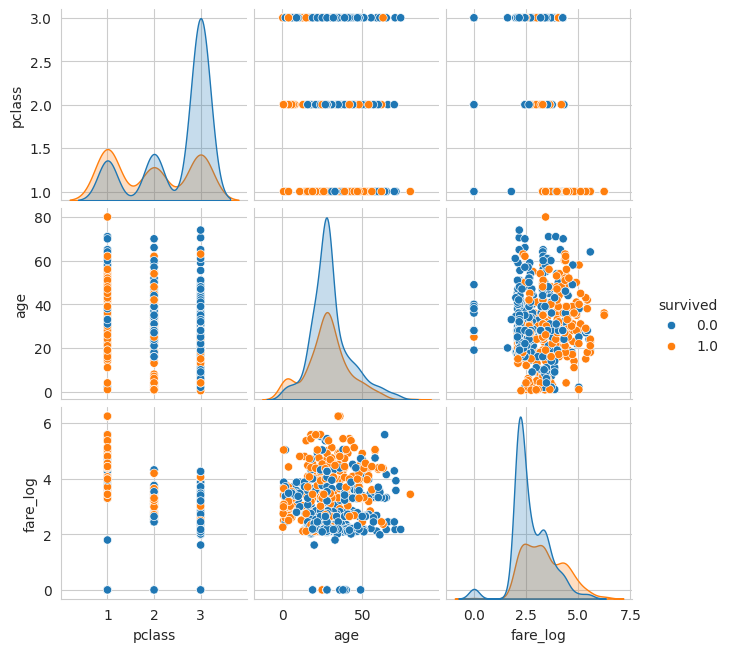

In [37]:
cols = ['survived', 'pclass', 'age', 'fare_log']
sns.pairplot(merged_left[cols].dropna(), hue='survived', diag_kind='kde', height=2.2)
plt.show()

**A word of caution:** pair plots get slow and cluttered fast — they scale roughly with
the *square* of the number of columns. Reserve them for a small, deliberately chosen subset of
features, not your entire dataset.

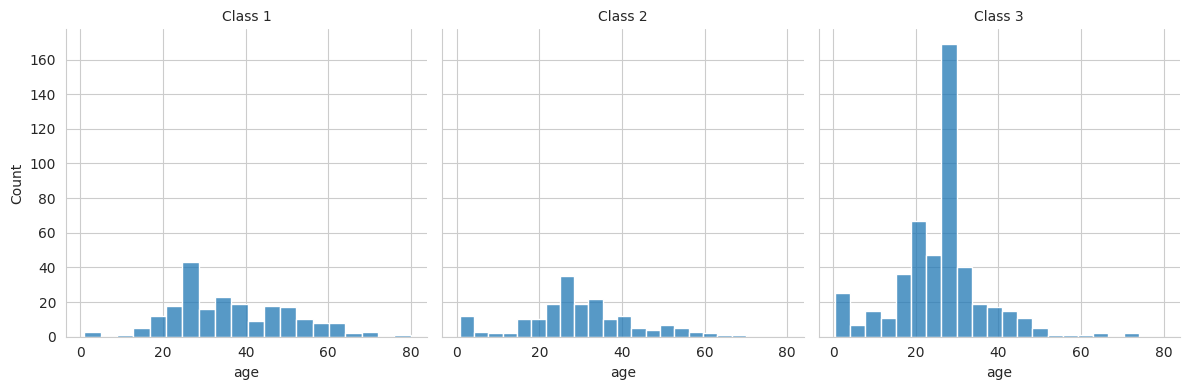

In [38]:
g = sns.FacetGrid(merged_left, col='pclass', height=4)
g.map(sns.histplot, 'age', bins=20)
g.set_titles('Class {col_name}')
plt.show()

## 5. Case Study: Who survived the Titanic, and why?

Now we bring everything from both parts together into a guided mini-analysis, the way you
would for a real stakeholder question: **what factors were associated with survival, and how
strong was each one?**

We'll work through this as a short sequence of questions, each answered with one chart.

**Question 1: Did passenger class matter?**

/tmp/ipykernel_715/1730966688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pclass', y='survived', data=merged_left, palette='Blues_d')


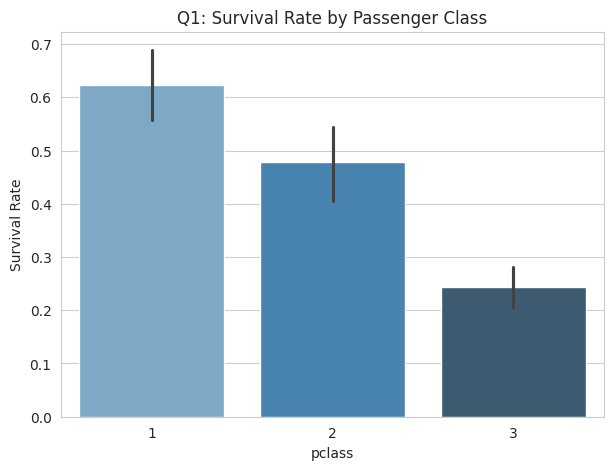

In [39]:
plt.figure(figsize=(7, 5))
sns.barplot(x='pclass', y='survived', data=merged_left, palette='Blues_d')
plt.ylabel('Survival Rate')
plt.title('Q1: Survival Rate by Passenger Class')
plt.show()

**Answer:** Yes, clearly — first class passengers survived at roughly double the rate of
third class passengers. This matches the negative correlation (`pclass` vs. `survived`) we saw
in the heatmap earlier.

**Question 2: Did sex matter more or less than class?**

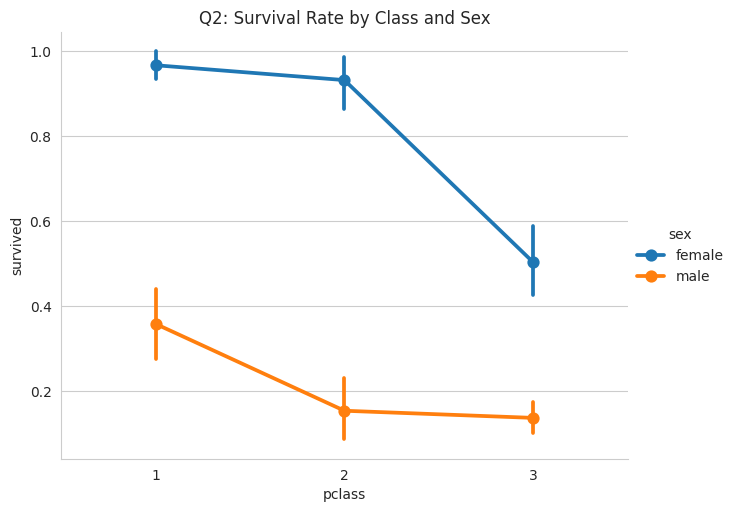

In [40]:
sns.catplot(x='pclass', y='survived', hue='sex', data=merged_left, kind='point', height=5, aspect=1.3)
plt.title('Q2: Survival Rate by Class and Sex')
plt.show()

**Answer:** Sex mattered *more* than class. The line for women sits dramatically above
the line for men at every class level — the gap between sexes within a class dwarfs the gap
between classes for the same sex.

**Question 3: Did age play a role, independent of class and sex?**

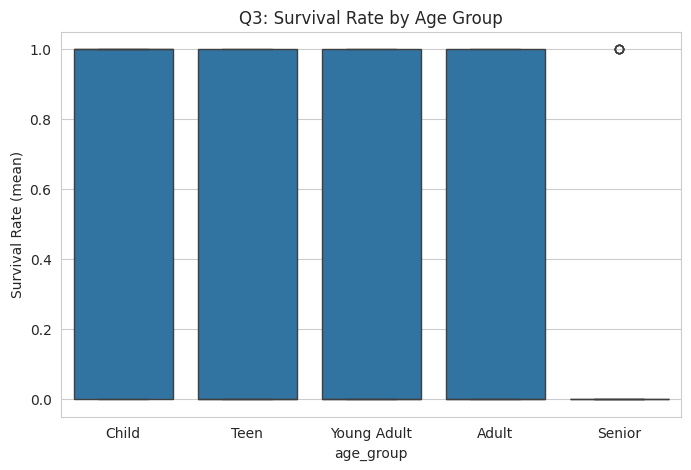

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='age_group', y='survived', data=merged_left,
            order=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
plt.title('Q3: Survival Rate by Age Group')
plt.ylabel('Survival Rate (mean)')
plt.show()

**Answer:** Children show a noticeably higher survival rate than other age groups,
consistent with a "women and children first" boarding pattern — though the effect is smaller
than the sex effect from Question 2.

**Question 4: Putting it together — fare, class, and survival in one view**

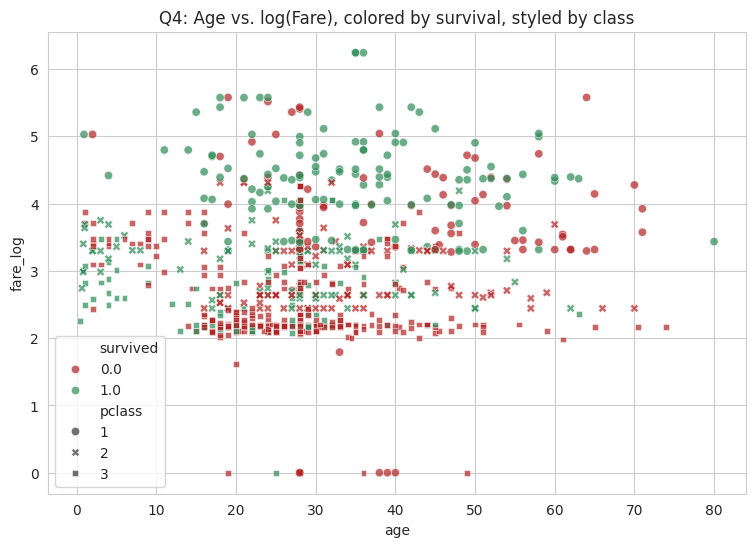

In [42]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='age', y='fare_log', hue='survived', style='pclass',
    data=merged_left, alpha=0.7, palette={0: 'firebrick', 1: 'seagreen'}
)
plt.title('Q4: Age vs. log(Fare), colored by survival, styled by class')
plt.show()

**Answer:** Survivors (green) cluster more toward the higher end of the fare axis,
across most ages, while non-survivors (red) are denser toward the bottom — consistent with
everything found in Questions 1–3, now visible as a single combined pattern rather than three
separate charts.

### Case study takeaway

Three variables — **class**, **sex**, and **age** — each independently relate to survival, with
sex showing the strongest separation of the three. None of this required a predictive model:
it came entirely from the cleaning, transforming, and visualizing covered in this notebook.
That's the point of a thorough EDA pass — by the time you're ready to model, you already know
roughly what the model *should* find, which makes it much easier to tell whether the model is
working correctly.


## Recap

**Part I — pandas:**
- Loading & inspecting: `read_csv`/`load_dataset`, `head`/`tail`/`shape`/`dtypes`/`describe`
- Missing data: `isnull`, percentages, `sns.heatmap`, `missingno` (`matrix`/`bar`/`heatmap`)
- Cleaning: `drop`, `fillna`, `dropna`, `drop_duplicates`, `.str` methods, `rename`
- Merging & joining: `pd.merge()` (`inner`/`left`/`right`/`outer`), `pd.concat()`
- Transformation: `map`, `apply`, `pd.cut` (binning), `pd.get_dummies` (encoding),
  `np.log1p` (skew correction), `groupby().agg()`

**Part II — matplotlib & seaborn:**
- matplotlib basics: `plt.figure`, `plt.subplots`, `plot`/`bar`/`hist`/`scatter`
- seaborn basics: `data=` interface, `set_style`, automatic confidence intervals
- Distributions: `histplot`, `boxplot`, `violinplot`, `countplot`
- Trends & relationships: `regplot`, `heatmap`, `catplot`, `pairplot`, `FacetGrid`, `scatterplot`
- Case study: chaining several of the above into a guided, question-by-question analysis

The natural next step beyond this notebook is **feature engineering and model training** —
but everything here is what makes those later steps tractable instead of guesswork.
